# Robust multi-lag advection benchmark (083126)

Fixed baselines: **M0 zero** and **M3 empirical $\tau=1$**. The new competitor M6 computes regular-grid empirical space-time semivariograms at $\tau=1,2,3$, maps displacement to velocity through $h=\tau v$, and combines relative surfaces using pair-count/contrast weights. No spatial-distance binning is used.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
OUT = REPO / 'outputs/summer_26/synthetic_multilag_advection_benchmark_corridor432_083126'
init = pd.read_csv(OUT / 'initializer_results.csv')
init_summary = pd.read_csv(OUT / 'initializer_summary.csv')
lags = pd.read_csv(OUT / 'multilag_diagnostics.csv')
full = pd.read_csv(OUT / 'full_fit_results.csv')
full_summary = pd.read_csv(OUT / 'full_fit_summary.csv')
runtime = json.loads((OUT / 'total_runtime.json').read_text())
print(f"initializer status ok: {init['status'].eq('ok').all()}")
print(f"full-fit status ok: {full['status'].eq('ok').all()}")
print(f"total runtime: {runtime['benchmark_wall_s']:.2f} s ({runtime['benchmark_wall_minutes']:.2f} min)")

initializer status ok: True
full-fit status ok: True
total runtime: 74.50 s (1.24 min)


## Multi-lag objective

For each lag, M6 evaluates $\widetilde\gamma_\tau(\tau v)=\widehat\gamma_\tau(\tau v)/\operatorname{median}_h\widehat\gamma_\tau(h)$ on a common velocity grid. The combined score is

$$Q(v)=\frac{\sum_\tau w_\tau\widetilde\gamma_\tau(\tau v)}{\sum_\tau w_\tau},\qquad w_\tau=\sqrt{8-\tau}\,c_\tau,$$

where $c_\tau=(\operatorname{median}\gamma_\tau-\min\gamma_\tau)/\operatorname{median}\gamma_\tau$. A lag is excluded if its minimum touches the search boundary or contrast is below 0.05.

## Initializer accuracy and time

In [2]:
display(init_summary.style.format({
    'mean_seed_s': '{:.4f}', 'median_seed_s': '{:.4f}',
    'mean_seed_error': '{:.5f}', 'median_seed_error': '{:.5f}',
    'max_seed_error': '{:.5f}', 'mean_angle_error_deg': '{:.3f}',
    'correct_quadrant_rate': '{:.0%}',
}))
display(init[['day','method','seed_lat','seed_lon','seed_error_euclid',
              'seed_angle_error_deg','seed_total_s','ridge_is_ambiguous']])

,method,n_days,mean_seed_s,median_seed_s,mean_seed_error,median_seed_error,max_seed_error,mean_angle_error_deg,correct_quadrant_rate
0,M0_zero,3,0.0000,0.0000,0.21541,0.21541,0.21541,nan,0%
1,M3_empirical_tau1,3,0.1268,0.1338,0.01360,0.01360,0.01360,3.166,100%
2,M6_robust_multilag,3,0.1859,0.1910,0.01640,0.01780,0.01780,2.756,100%


,day,method,seed_lat,seed_lon,seed_error_euclid,seed_angle_error_deg,seed_total_s,ridge_is_ambiguous
0,2023-07-01,M0_zero,0.000,0.000,0.215407,NaN,0.000000,NaN
1,2023-07-01,M3_empirical_tau1,0.088,-0.189,0.013601,3.165676,0.112454,False
2,2023-07-01,M6_robust_multilag,0.066,-0.189,0.017804,2.551884,0.167993,False
3,2023-07-02,M0_zero,0.000,0.000,0.215407,NaN,0.000000,NaN
4,2023-07-02,M3_empirical_tau1,0.088,-0.189,0.013601,3.165676,0.133843,False
5,2023-07-02,M6_robust_multilag,0.088,-0.189,0.013601,3.165676,0.191030,False
6,2023-07-03,M0_zero,0.000,0.000,0.215407,NaN,0.000000,NaN
7,2023-07-03,M3_empirical_tau1,0.088,-0.189,0.013601,3.165676,0.134069,False
8,2023-07-03,M6_robust_multilag,0.066,-0.189,0.017804,2.551884,0.198643,True


## Lag diagnostics

Day 3, $\tau=3$ selects a boundary minimum and is therefore excluded from the combined score. This is an example where blindly averaging all temporal lags would make the estimator less robust.

In [3]:
display(lags[['day','tau','n_temporal_pairs','grid_seed_lat','grid_seed_lon',
              'relative_contrast','lag_weight','used_in_combination',
              'minimum_boundary','minimum_pair_count']].style.format({
    'grid_seed_lat': '{:.5f}', 'grid_seed_lon': '{:.5f}',
    'relative_contrast': '{:.3f}', 'lag_weight': '{:.3f}',
}))

,day,tau,n_temporal_pairs,grid_seed_lat,grid_seed_lon,relative_contrast,lag_weight,used_in_combination,minimum_boundary,minimum_pair_count
0,2023-07-01,1,7,0.08800,-0.18900,0.376,0.995,True,False,17556
1,2023-07-01,2,6,0.06600,-0.18900,0.281,0.688,True,False,13954
2,2023-07-01,3,5,0.05867,-0.18900,0.243,0.544,True,False,10724
3,2023-07-02,1,7,0.08800,-0.18900,0.396,1.048,True,False,17487
4,2023-07-02,2,6,0.11000,-0.18900,0.333,0.816,True,False,13219
5,2023-07-02,3,5,0.10267,-0.18900,0.230,0.514,True,False,9916
6,2023-07-03,1,7,0.08800,-0.18900,0.336,0.889,True,False,17553
7,2023-07-03,2,6,0.06600,-0.18900,0.208,0.509,True,False,13931
8,2023-07-03,3,5,0.01467,-0.44100,0.107,0.000,False,True,8943


## Downstream seven-parameter fit

All seven parameters are free with identical nuisance starts and one L-BFGS outer call (`max_eval=10`). The seed-specific directional corridor is constructed once and held fixed.

,method,n_days,mean_final_nll,mean_final_advection_error,mean_final_rmsre_7param,mean_final_fit_s,mean_end_to_end_s
0,M0_zero,3,1.134876,0.00878,0.03081,7.748,7.748
1,M3_empirical_tau1,3,1.128689,0.00681,0.03237,7.885,8.012
2,M6_robust_multilag,3,1.128703,0.00664,0.03264,7.945,8.131


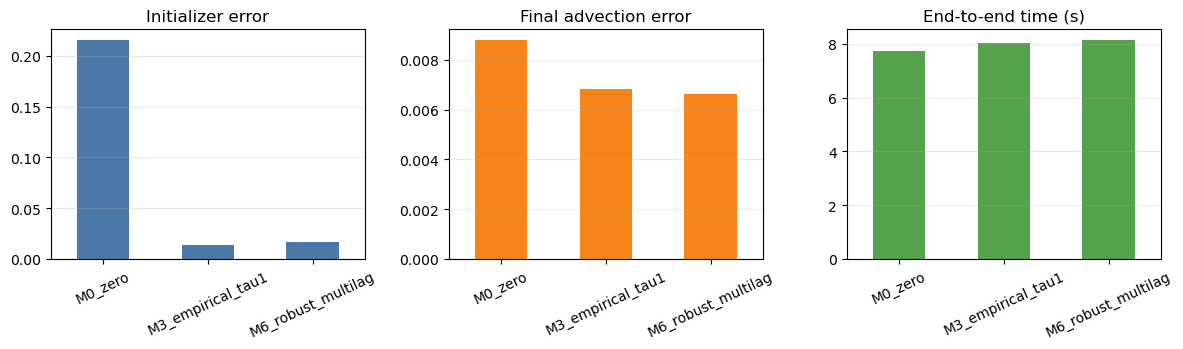

In [4]:
display(full_summary.style.format({
    'mean_final_nll': '{:.6f}', 'mean_final_advection_error': '{:.5f}',
    'mean_final_rmsre_7param': '{:.5f}', 'mean_final_fit_s': '{:.3f}',
    'mean_end_to_end_s': '{:.3f}',
}))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
init_summary.plot.bar(x='method', y='mean_seed_error', legend=False, ax=axes[0], color='#4C78A8')
full_summary.plot.bar(x='method', y='mean_final_advection_error', legend=False, ax=axes[1], color='#F58518')
full_summary.plot.bar(x='method', y='mean_end_to_end_s', legend=False, ax=axes[2], color='#54A24B')
axes[0].set_title('Initializer error'); axes[1].set_title('Final advection error'); axes[2].set_title('End-to-end time (s)')
for ax in axes: ax.set_xlabel(''); ax.tick_params(axis='x', rotation=25); ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()

## Conclusion

On these three synthetic days, M3 remains the best standalone initializer: mean vector error 0.01360 in 0.1268 s. M6 reduces mean direction error from 3.166° to 2.756° but increases vector error to 0.01640 and time to 0.1859 s.

After the equal-budget full fit, M6 has a slightly lower mean final advection error (0.00664 versus 0.00681), while M3 has a slightly lower mean NLL (1.128689 versus 1.128703) and lower end-to-end time (8.012 versus 8.131 s). These differences are too small to claim that M6 beats M3. The useful contribution of multi-lag is currently diagnostic robustness—especially detecting the failed day-3 tau-3 ridge—not a clear accuracy gain.